# 2D CNN 高光谱分类教学 Notebook

这份 Notebook 以 `Indian Pines` 为例，演示如何使用 **2D CNN** 完成高光谱图像分类。

2D CNN 的核心思路是：

- 先把高光谱数据在光谱维度上做降维
- 再把每个像素周围的空间邻域切成二维 patch
- 把降维后的多个主成分看成输入通道，交给 `Conv2d` 学习空间结构


## 这份 Notebook 会完成什么

1. 读取 `Indian Pines` 数据与标签
2. 用 PCA 压缩光谱维度
3. 构造二维 patch 样本
4. 训练一个轻量 2D CNN
5. 评估 OA、AA、Kappa 和分类报告
6. 生成整图预测结果并保存


In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


## 1. 读取数据

`Indian Pines` 的数据立方体形状是 `(height, width, bands)`，标签图形状是 `(height, width)`。
标签值 `0` 表示背景，非零值表示真实地物类别。


In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"]
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"]

class_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']

print("cube shape:", cube.shape)
print("gt shape:", gt.shape)
print("dtype:", cube.dtype, gt.dtype)
print("num classes:", len(class_names))
print("labeled pixels:", int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
dtype: uint16 uint8
num classes: 16
labeled pixels: 10249


In [3]:
unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({"label": unique, "count": counts})
class_count_df = class_count_df[class_count_df["label"] != 0].copy()
class_count_df["class_name"] = class_count_df["label"].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[["label", "class_name", "count"]].sort_values("label")
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


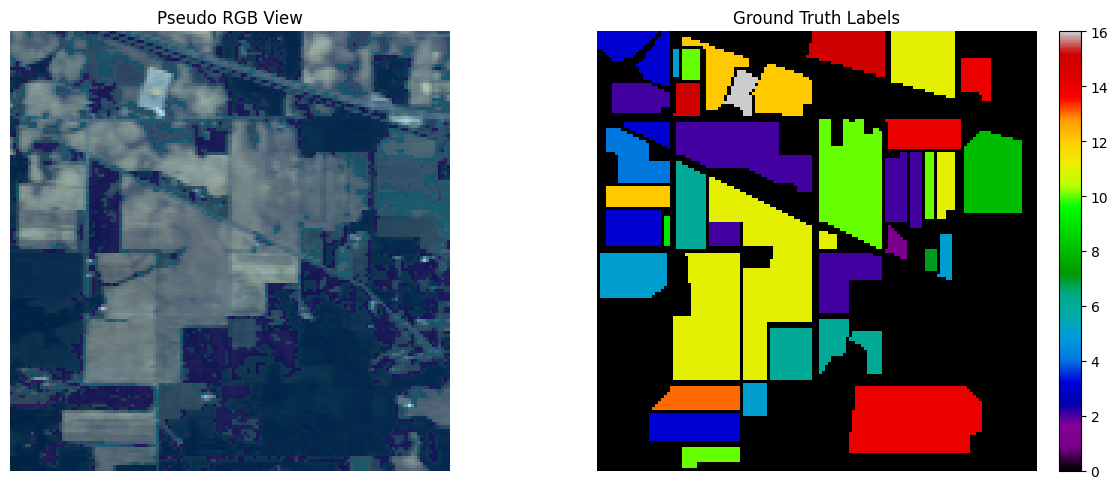

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB View")
axes[0].axis("off")

im = axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. 为什么 2D CNN 需要先做 PCA

对 2D CNN 来说，输入是二维 patch，卷积主要发生在空间维度上。
如果直接把原始 200 个波段全部作为通道，模型会更重，也更难训练。

因此这里先用 PCA 把光谱维度压缩到较小数量，再把这些主成分当作输入通道。


In [5]:
PCA_COMPONENTS = 12

flat_cube = cube.reshape(-1, cube.shape[2]).astype(np.float32)
pca = PCA(n_components=PCA_COMPONENTS, whiten=True)
reduced_flat = pca.fit_transform(flat_cube).astype(np.float32)
reduced_cube = reduced_flat.reshape(cube.shape[0], cube.shape[1], PCA_COMPONENTS)

print("reduced cube shape:", reduced_cube.shape)
print("explained variance ratio sum:", float(pca.explained_variance_ratio_.sum()))


reduced cube shape: (145, 145, 12)
explained variance ratio sum: 0.9743319749832153


## 3. 划分训练 / 验证 / 测试集

这里只保留有标签的像素，然后按类别分层抽样。


In [6]:
mask = gt != 0
positions = np.argwhere(mask)
labels = gt[mask].astype(np.int64) - 1

TRAIN_RATIO = 0.1
VAL_RATIO = 0.1
TEST_RATIO = 0.8

pos_train, pos_temp, y_train, y_temp = train_test_split(
    positions,
    labels,
    train_size=TRAIN_RATIO,
    stratify=labels,
    random_state=SEED,
)

val_ratio_within_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
pos_val, pos_test, y_val, y_test = train_test_split(
    pos_temp,
    y_temp,
    train_size=val_ratio_within_temp,
    stratify=y_temp,
    random_state=SEED,
)

print("train samples:", len(pos_train))
print("val samples:", len(pos_val))
print("test samples:", len(pos_test))


train samples: 1024
val samples: 1025
test samples: 8200


In [7]:
def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({"label": int(v + 1), "class_name": class_names[v], "count": int(c)})
    return pd.DataFrame(rows)


split_summary = pd.concat(
    [
        count_by_class(y_train, class_names).assign(split="train"),
        count_by_class(y_val, class_names).assign(split="val"),
        count_by_class(y_test, class_names).assign(split="test"),
    ],
    ignore_index=True,
)

split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,5,train
1,2,Corn-notill,143,train
2,3,Corn-mintill,83,train
3,4,Corn,24,train
4,5,Grass-pasture,48,train
5,6,Grass-trees,73,train
6,7,Grass-pasture-mowed,3,train
7,8,Hay-windrowed,48,train
8,9,Oats,2,train
9,10,Soybean-notill,97,train


## 4. 标准化与 patch 构造

这里先按像素对 PCA 特征做标准化，再用标准化后的立方体构造二维 patch。


In [8]:
train_pixels = reduced_cube[pos_train[:, 0], pos_train[:, 1]]
scaler = StandardScaler()
scaler.fit(train_pixels)

reduced_flat_scaled = scaler.transform(reduced_cube.reshape(-1, reduced_cube.shape[2])).astype(np.float32)
reduced_cube_scaled = reduced_flat_scaled.reshape(reduced_cube.shape)

PATCH_SIZE = 9
BATCH_SIZE = 256


class PatchDataset2D(Dataset):
    def __init__(self, cube, positions, labels=None, patch_size=9):
        self.patch_size = patch_size
        self.labels = labels
        self.positions = np.asarray(positions)
        pad = patch_size // 2
        self.cube = np.pad(cube, ((pad, pad), (pad, pad), (0, 0)), mode="constant")
        self.pad = pad

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        r, c = self.positions[idx]
        rp, cp = r + self.pad, c + self.pad
        p = self.patch_size // 2
        patch = self.cube[rp - p : rp + p + 1, cp - p : cp + p + 1]
        patch = torch.from_numpy(patch.transpose(2, 0, 1).astype(np.float32))
        if self.labels is None:
            return patch
        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return patch, label


train_ds = PatchDataset2D(reduced_cube_scaled, pos_train, y_train, PATCH_SIZE)
val_ds = PatchDataset2D(reduced_cube_scaled, pos_val, y_val, PATCH_SIZE)
test_ds = PatchDataset2D(reduced_cube_scaled, pos_test, y_test, PATCH_SIZE)
all_ds = PatchDataset2D(reduced_cube_scaled, positions, labels=None, patch_size=PATCH_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
all_loader = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([256, 12, 9, 9])

## 5. 定义 2D CNN

这个网络把 PCA 主成分当作输入通道，通过二维卷积提取空间纹理与局部上下文信息。


In [9]:
class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SpectralSpatialCNN2D(in_channels=PCA_COMPONENTS, num_classes=len(class_names)).to(device)
model


SpectralSpatialCNN2D(
  (features): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_feat

In [10]:
@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0

    for batch in data_loader:
        xb, yb = batch
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
}


## 6. 训练模型

这里记录训练损失、训练准确率和验证准确率，并保留验证集最优模型。


In [11]:
best_state = None
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

print("best_val_acc =", round(best_val_acc, 4))


Epoch 01/10 | loss=2.6433 | train_acc=0.2559 | val_acc=0.2351
Epoch 02/10 | loss=2.3297 | train_acc=0.5420 | val_acc=0.5415
Epoch 03/10 | loss=2.0977 | train_acc=0.5400 | val_acc=0.5424
Epoch 04/10 | loss=1.8517 | train_acc=0.5625 | val_acc=0.5424
Epoch 05/10 | loss=1.6572 | train_acc=0.5557 | val_acc=0.5463


Epoch 06/10 | loss=1.4810 | train_acc=0.5635 | val_acc=0.5707
Epoch 07/10 | loss=1.3544 | train_acc=0.5908 | val_acc=0.6068
Epoch 08/10 | loss=1.2173 | train_acc=0.6123 | val_acc=0.6185
Epoch 09/10 | loss=1.0889 | train_acc=0.6348 | val_acc=0.6498
Epoch 10/10 | loss=0.9965 | train_acc=0.6738 | val_acc=0.6868
best_val_acc = 0.6868


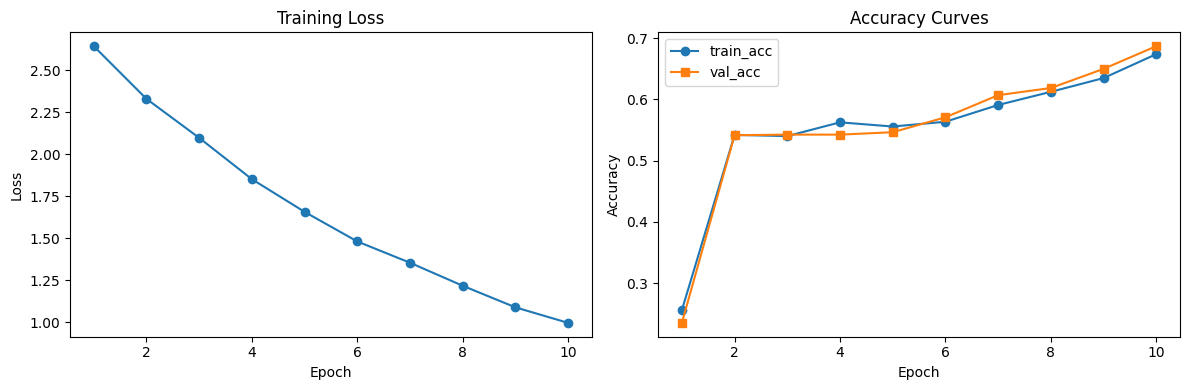

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epoch_index, history["train_acc"], marker="o", label="train_acc")
axes[1].plot(epoch_index, history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. 测试集评估

常见指标包括：

- `OA`：Overall Accuracy
- `AA`：Average Accuracy
- `Kappa`：考虑随机一致性的评价指标


In [13]:
model.load_state_dict(best_state)
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average="macro", zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

print("Test accuracy:", round(test_acc, 4))
print("OA:", round(oa, 4))
print("AA:", round(aa, 4))
print("Kappa:", round(kappa, 4))


Test accuracy: 0.7056
OA: 0.7056
AA: 0.4957
Kappa: 0.6551


In [14]:
report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     0.0000    0.0000    0.0000        37
                 Corn-notill     0.5808    0.7715    0.6627      1142
                Corn-mintill     0.3158    0.0090    0.0176       664
                        Corn     0.0000    0.0000    0.0000       189
               Grass-pasture     0.9958    0.6150    0.7604       387
                 Grass-trees     0.7856    0.9914    0.8766       584
         Grass-pasture-mowed     0.0000    0.0000    0.0000        22
               Hay-windrowed     0.8986    0.9974    0.9454       382
                        Oats     0.0000    0.0000    0.0000        16
              Soybean-notill     0.6619    0.7147    0.6873       778
             Soybean-mintill     0.6711    0.9293    0.7793      1965
               Soybean-clean     0.6870    0.1895    0.2970       475
                       Wheat     0.7617    0.9939    0.8624       164
                   

## 8. 整图预测

训练完成后，对全部有标签像素构造 patch 并批量推理，再把结果还原成二维分类图。


In [15]:
@torch.no_grad()
def predict_all(model, data_loader):
    model.eval()
    preds = []
    for xb in data_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


all_pred = predict_all(model, all_loader)
pred_map = np.zeros_like(gt)
pred_map[positions[:, 0], positions[:, 1]] = all_pred + 1

print("pred_map shape:", pred_map.shape)
print("nonzero predictions:", int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


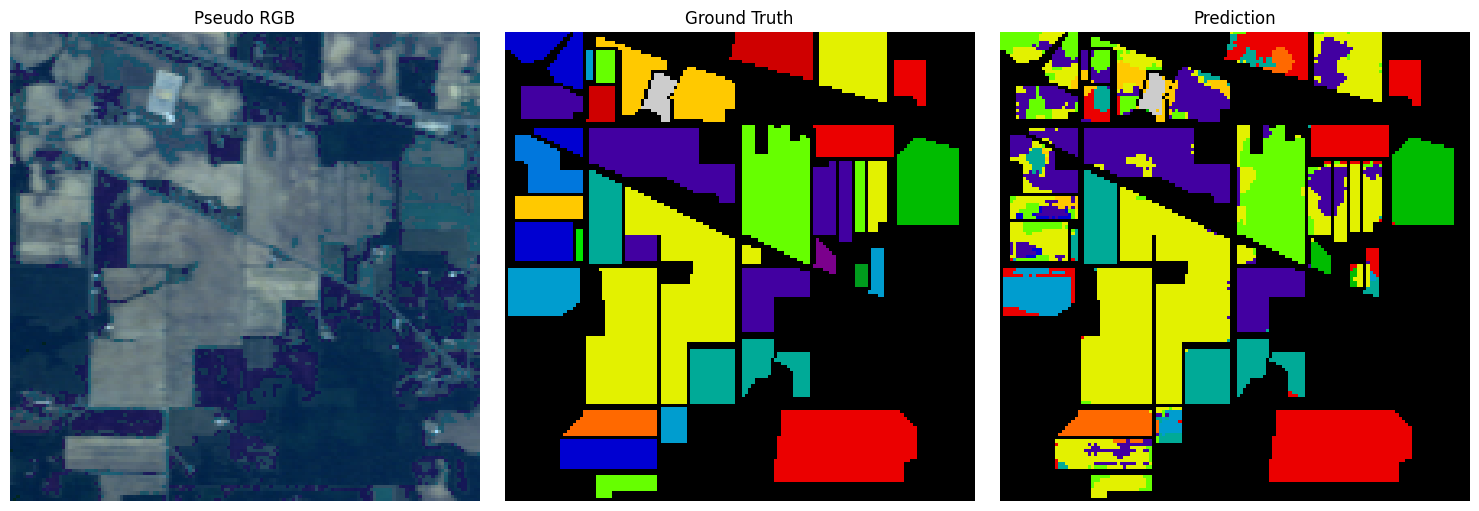

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("Pseudo RGB")
axes[0].axis("off")

axes[1].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 9. 保存结果

这里把指标、训练曲线和预测图保存到 `results/2dcnn/IP_notebook/`。


In [17]:
output_dir = Path("results/2dcnn/IP_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    "seed": SEED,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "oa": float(oa),
    "aa": float(aa),
    "kappa": float(kappa),
    "best_val_acc": float(best_val_acc),
}

(output_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(output_dir / "classification_report.txt").write_text(report, encoding="utf-8")
split_summary.to_csv(output_dir / "split_summary.csv", index=False)
class_count_df.to_csv(output_dir / "class_distribution.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].plot(np.arange(1, EPOCHS + 1), history["train_acc"], marker="o", label="train_acc")
axes[1].plot(np.arange(1, EPOCHS + 1), history["val_acc"], marker="s", label="val_acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "training_curves.png", dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(pred_map, cmap="nipy_spectral", vmin=0, vmax=len(class_names))
axes[1].set_title("Prediction")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(output_dir / "prediction_map.png", dpi=200)
plt.close(fig)

print("saved to", output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\2dcnn\IP_notebook
['class_distribution.csv', 'classification_report.txt', 'metrics.json', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 10. 小结

2D CNN 的特点是：

- 更强调空间邻域结构
- 通常需要先做 PCA 降维
- 相比像素级 1D CNN，更能利用局部空间纹理
